In [5]:
import random, math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, random_unitary, negativity, DensityMatrix, random_quantum_channel, Choi, random_clifford
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
 
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [6]:
# Prepare a GHZ state

def GHZ_state(circuit, L):
    circuit.h(0)
    for qubit in range(1, L):
        circuit.cx(0, qubit)

# Random quantum channel function

def rqc(circuit, L, p_rqc):
    for i in range(L):
        if random.random() < p_rqc:
            depolarizingchannel = random_quantum_channel(2)
            circuit.append(depolarizingchannel, [i])
        
# Clifford gate random brickwork circuit function

def random_brickwork_circuit(L, p_rqc):
    circuit = QuantumCircuit(L, L**2)

    GHZ_state(circuit, L)

    for t in range(40):
        circuit.save_density_matrix(label=f"dm_{t}")
        rqc(circuit, L, p_rqc)
        if t % 2 == 0:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                circuit.unitary(gate, [2*i, 2*i+1], label=" ")
        else:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                if 2*i == L-2:
                    circuit.unitary(gate, [L-1, 0], label=" ")
                else:
                    circuit.unitary(gate, [2*i+1, 2*i+2], label=" ")

    # circuit.measure_all()
    return circuit

# Logarithmic Negativity Function

def calculate_log_negativity(dm, subsystem):
    if dm is None:
        raise ValueError("Density matrix is None")
    
    # Convert Aer DensityMatrix to standard Qiskit DensityMatrix
    try:
        if hasattr(dm, 'data'):
            rho = DensityMatrix(dm.data)
        else:
            rho = DensityMatrix(dm)
    except Exception as e:
        print(f"Error converting density matrix: {e}")
        print(f"Type: {type(dm)}")
        if hasattr(dm, 'data'):
            print(f"Data type: {type(dm.data)}")
            print(f"Data shape: {dm.data.shape if hasattr(dm.data, 'shape') else 'no shape'}")
        raise
        
    negv = negativity(rho, subsystem)
    log_negv = math.log(2 * negv + 1, 2)
    return log_negv

# # Create circuit

# circuit = random_brickwork_circuit(4, 0.5)

# # Draw circuit

# circuit.draw("mpl")

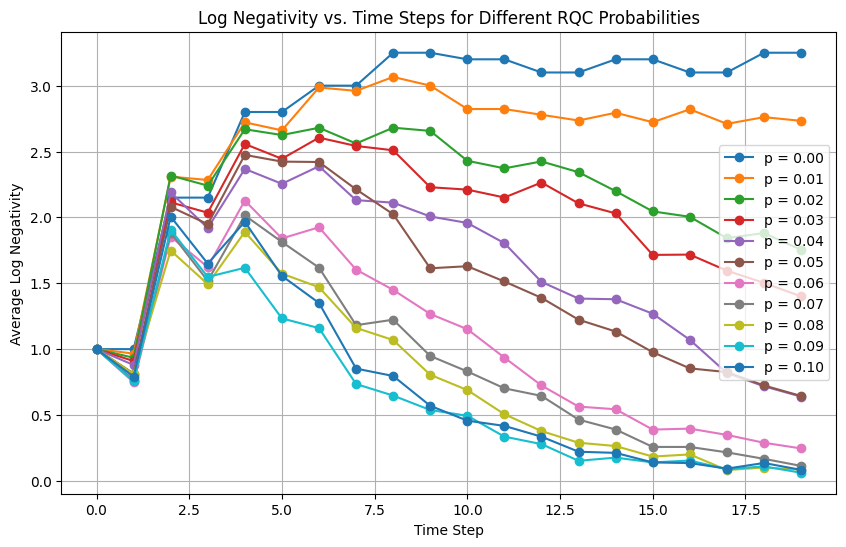

In [3]:
# Number of Qubits, RQC P Value Range,

L = 8
p_values = np.arange(0, 0.11, 0.01)
time_steps = list(range(20))

num_runs = 20
num_samples = len(time_steps) * num_runs

results = {}
results_std = {}

# Loop over all P Values for fixed Qubit number

for p in p_values:
    final_log_negv = []
    for i in range(num_runs):

        circuit = random_brickwork_circuit(L, p)
        # depo_err_chan = depolarizing_error(round(1-p, 2), 1)

        # Noise model

        # noise_model = NoiseModel()
        # noise_model.add_basis_gates(['unitary'])
        # noise_model.add_all_qubit_quantum_error(depo_err_chan, ["dp"])
        # sim_noise = AerSimulator(noise_model=noise_model)
        sim = AerSimulator()

        # Job

        # job = sim_noise.run(circuit)
        # result = job.result().data()

        job = sim.run(circuit)
        result = job.result().data()

        # Get Density Matrices

        log_negv_runs = []

        for t in time_steps:

            dm = result.get(f"dm_{t}")

            # Calculate negativity

            log_negv = calculate_log_negativity(dm, list(range(int(L/2))))
            log_negv_runs.append(log_negv)

        final_log_negv.append(log_negv_runs)

    results[p] = np.mean(final_log_negv, axis = 0)
    results_std[p] = np.std(final_log_negv, axis = 0)

    # print(results[p])

# Plot results

plt.figure(figsize=(10, 6))

for p, avg_log_negv in results.items():
    plt.plot(time_steps, avg_log_negv, label=f"p = {p:.2f}", marker ="o")
    
plt.xlabel("Time Step")
plt.ylabel("Average Log Negativity")
plt.title("Log Negativity vs. Time Steps for Different RQC Probabilities")
plt.legend()
plt.grid()
plt.show()

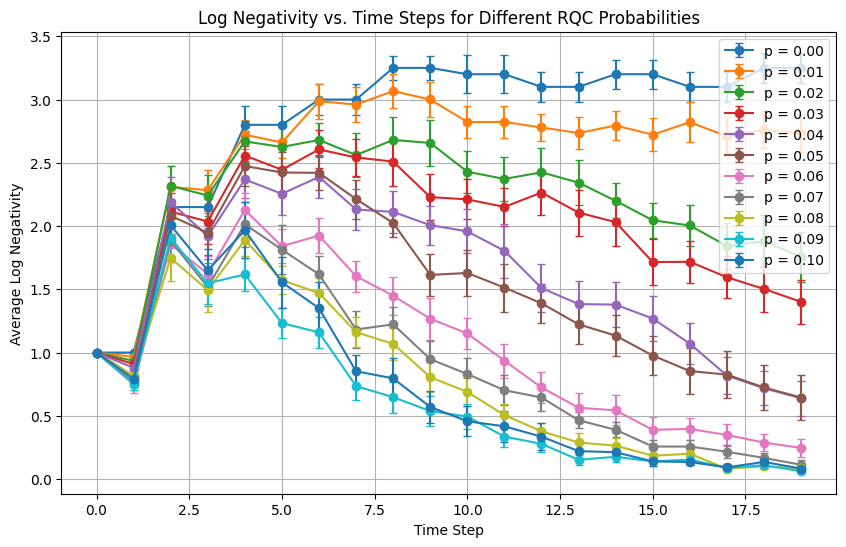

In [4]:
# Calculate Standard Error
results_se = {p: stds / np.sqrt(num_runs) for p, stds in results_std.items()}

# Plot results with error bars
plt.figure(figsize=(10, 6))

for p, avg_log_negv in results.items():
    se = results_se[p]  # Get the standard error for this p-value
    plt.errorbar(time_steps, avg_log_negv, yerr=se, label=f"p = {p:.2f}", marker="o", capsize=3)

# Customize the plot
plt.xlabel("Time Step")
plt.ylabel("Average Log Negativity")
plt.title("Log Negativity vs. Time Steps for Different RQC Probabilities")
plt.legend()
plt.grid()
plt.show()

/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_21166/1327833317.py:4: RuntimeWarning: invalid value encountered in divide
  return (np.log(a)) / np.log(p) + c
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_21166/1327833317.py:4: RuntimeWarning: divide by zero encountered in divide
  return (np.log(a)) / np.log(p) + c
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_21166/1327833317.py:80: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(model_function, p_values_filtered, time_steps_filtered, p0=initial_guess)
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_21166/1327833317.py:4: RuntimeWarning: invalid value encountered in divide
  return (np.log(a)) / np.log(p) + c
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipykernel_21166/1327833317.py:4: RuntimeWarning: divide by zero encountered in divide
  return (np.log(a)) / np.log(p) + c
/var/folders/y3/4vzyq39s1k9bsd1jp6hr7j4c0000gn/T/ipyker

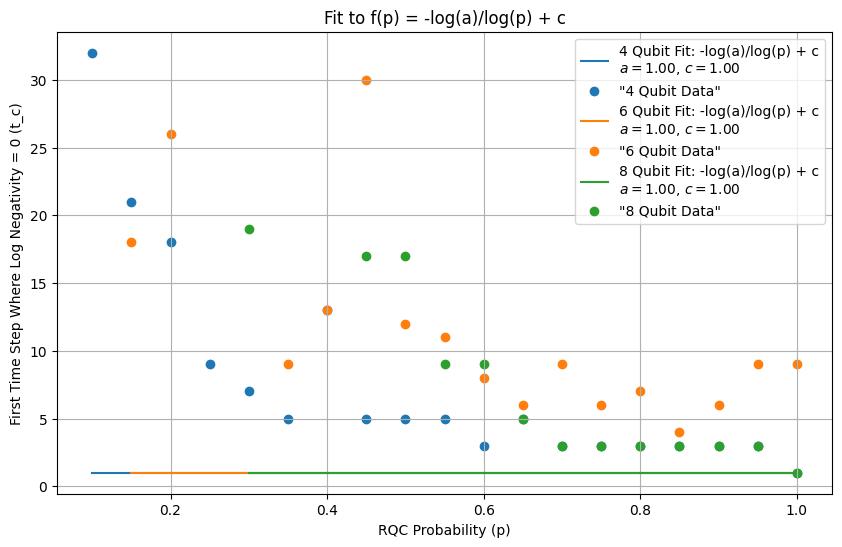

In [8]:
# Define Best Fit function f(p)

def model_function(p, a, c):
    return (np.log(a)) / np.log(p) + c

# Function to analyze negativity for a given number of qubits

def analyze_negativity_for_qubits(L, p_values, num_runs):
    time_steps = list(range(40))
    results = {}
    first_zero_time_steps = {p: None for p in p_values}

    # Loop over all P values

    for p in p_values:
        final_log_negv = []
        for _ in range(num_runs):
            # Generate circuit and noise

            circuit = random_brickwork_circuit(L, p)

            # Noise model

            sim = AerSimulator()

            # Job

            job = sim.run(circuit)
            result = job.result().data()

            # Get density matrices and calculate negativity

            log_negv_runs = []
            for t in time_steps:
                dm = result.get(f"dm_{t}")
                log_negv = calculate_log_negativity(dm, list(range(int(L / 2))))
                log_negv_runs.append(log_negv)

            final_log_negv.append(log_negv_runs)

        # Average results

        results[p] = np.mean(final_log_negv, axis=0)

        # Find the first time step where negativity is zero

        first_zero_time_steps[p] = next(
            (t for t, val in enumerate(results[p][1:], start=1) if val <= 1e-2),
            None,
        )

    # Extract data for plotting

    p_values_filtered = [p for p, t in first_zero_time_steps.items() if t is not None]
    time_steps_filtered = [t for t in first_zero_time_steps.values() if t is not None]

    return p_values_filtered, time_steps_filtered

# Parameters

p_values = np.arange(0, 1.05, 0.05)
num_runs = 20
qubit_counts = [4, 6, 8]

# Plot results for each qubit count

plt.figure(figsize=(10, 6))

for L in qubit_counts:
    p_vals, t_steps = analyze_negativity_for_qubits(L, p_values, num_runs)

    # Filtered data

    p_values_filtered = np.array(p_vals)
    time_steps_filtered = np.array(t_steps)

    # Fit model to data

    initial_guess = [1.0, 1.0]  # Initial guess for [a, c]
    params, covariance = curve_fit(model_function, p_values_filtered, time_steps_filtered, p0=initial_guess)

    # Extract fitted parameters
    a_fitted, c_fitted = params

    # Generate fitted curve
    
    p_fit = np.linspace(min(p_values_filtered), max(p_values_filtered), 500)  # Smooth p range
    f_fit = model_function(p_fit, a_fitted, c_fitted)  # Fitted function values

    # Plot data and fit

    plt.plot(p_fit, f_fit, label=f"{L} Qubit Fit: -log(a)/log(p) + c\n$a={a_fitted:.2f}$, $c={c_fitted:.2f}$")
    plt.scatter(p_values_filtered, time_steps_filtered, label=f'"{L} Qubit Data"', marker="o")

# Formatting the plot

plt.xlabel("RQC Probability (p)")
plt.ylabel("First Time Step Where Log Negativity = 0 (t_c)")
plt.title("Fit to f(p) = -log(a)/log(p) + c")
plt.grid()
plt.legend()
plt.show()